#### Clustering

Let's use the popular Wine dataset from sklearn, which contains chemical properties of wines from three different cultivars.

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score


In [4]:
# Load the Wine dataset
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


C:\Users\Lbundi\AppData\Local\Temp\ipykernel_19724\1142507148.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df_pca[:, 0], df_pca[:, 1], s=50, cmap='viridis')


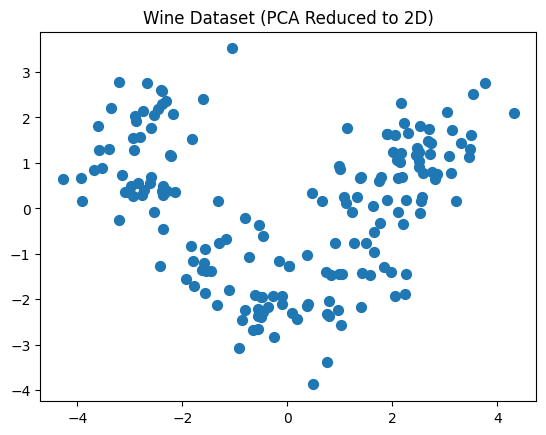

In [5]:
# Scale the data for clustering
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Dimensionality reduction for visualization purposes (PCA to 2D)
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Plotting the dataset after PCA transformation
plt.scatter(df_pca[:, 0], df_pca[:, 1], s=50, cmap='viridis')
plt.title('Wine Dataset (PCA Reduced to 2D)')
plt.show()

K-Means is an unsupervised algorithm that divides the data into k clusters. We will fit K-Means and visualize the results

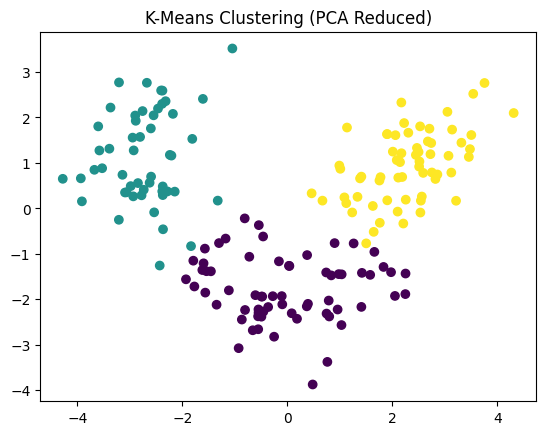

In [7]:
# Applying K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(df_scaled)

# Visualizing K-Means clusters
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df['cluster_kmeans'], cmap='viridis')
plt.title('K-Means Clustering (PCA Reduced)')
plt.show()


To avoid local minima, K-Means uses multiple initializations of centroids. We can see the effect by specifying n_init.

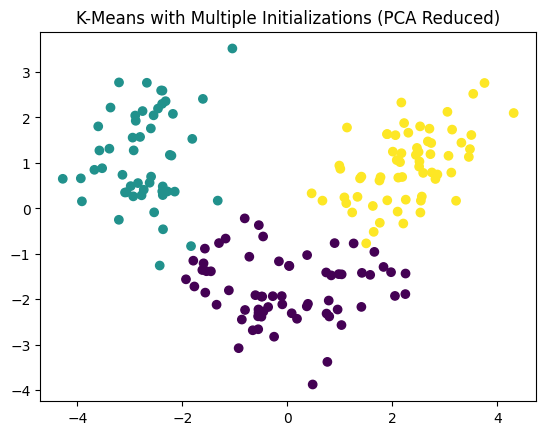

In [9]:
# K-Means with multiple initializations
kmeans_multiple_init = KMeans(n_clusters=3, n_init=10, random_state=42)
df['cluster_kmeans_multi'] = kmeans_multiple_init.fit_predict(df_scaled)

# Plot the clusters
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df['cluster_kmeans_multi'], cmap='viridis')
plt.title('K-Means with Multiple Initializations (PCA Reduced)')
plt.show()


1. Elbow Method

The Elbow Method is used to find the optimal number of clusters by analyzing the inertia (or within-cluster sum of squared distances) as a function of the number of clusters. Here's how to interpret it:

Inertia measures how spread out the points are within each cluster.
Lower inertia values mean tighter clusters, which is desirable.
As the number of clusters increases, inertia decreases because the points are divided into more clusters, and each cluster becomes more compact.

2. Silhouette Score

The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to 1, where:

-  1 means the data point is very well matched to its own cluster and poorly matched to neighboring clusters.
-  0 means the data point lies on the boundary between two clusters.
- -1 means the data point might be in the wrong cluster.

Finding the Optimal Number of Clusters


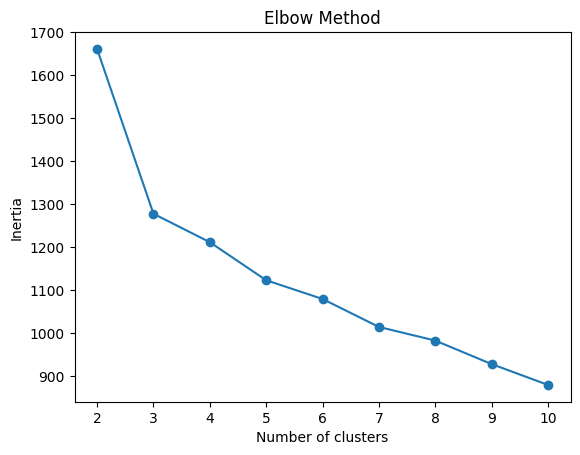

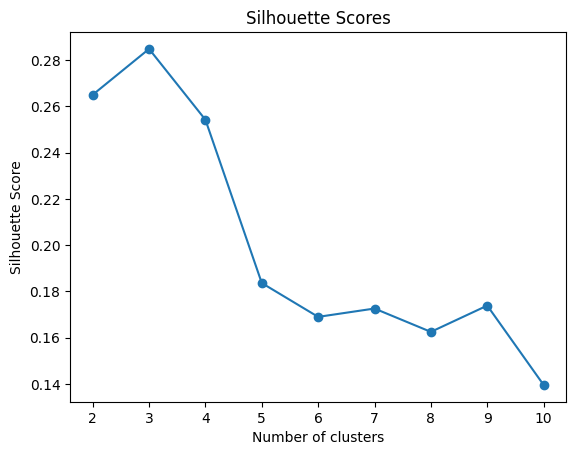

In [10]:
# Elbow Method
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Silhouette Score for each number of clusters
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()



We are Look for a point where the inertia starts decreasing more slowly (forming an "elbow" shape). This point indicates the optimal number of clusters, as adding more clusters beyond this point doesn’t significantly reduce inertia. The "elbow" point suggests a balance between having fewer clusters and minimizing within-cluster variance.

---
---
The optimal number of clusters is the one that maximizes the silhouette score.A higher score indicates well-defined, compact clusters.

**Limits of K-Means**

K-Means has limitations: it assumes spherical clusters and struggles with clusters of varying density or size. To explore this, we'll visualize how K-Means performs on the dataset.

1. Spherical Clusters Assumption
K-Means assumes that the clusters are spherical or roughly circular in shape. This assumption arises because the algorithm minimizes the Euclidean distance from each point to its assigned cluster center. However, real-world data may have clusters that are:

- Elliptical
- Irregularly shaped
- Overlapping or adjacent
- K-Means will not perform well when clusters deviate from this spherical shape


2. Difficulty with Clusters of Varying Density and Size

K-Means tries to partition the data into clusters of roughly equal size, but in many datasets:

- Some clusters may be larger or smaller in size than others.
- Some clusters may have high density (many points close together) while others are sparser.
- Since K-Means minimizes the distance between points and the centroid, it tends to create clusters of similar size and density. It can therefore:Split larger clusters into multiple smaller ones.Merge small but dense clusters with larger, less dense clusters.

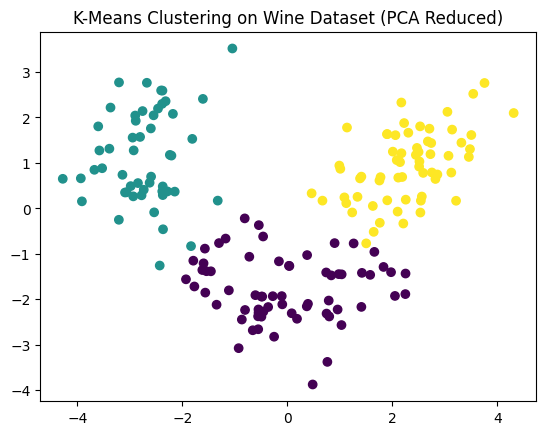

Davies-Bouldin Score (K-Means): 1.3891879777181646


In [12]:
# Evaluate K-Means using Davies-Bouldin score (a measure of cluster quality)
kmeans_final = KMeans(n_clusters=3, random_state=42)
kmeans_final.fit(df_scaled)
labels_kmeans = kmeans_final.labels_

# Visualize the clusters
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_kmeans, cmap='viridis')
plt.title('K-Means Clustering on Wine Dataset (PCA Reduced)')
plt.show()

# Davies-Bouldin Score (lower is better, measures the ratio of intra-cluster to inter-cluster distance)
db_score = davies_bouldin_score(df_scaled, labels_kmeans)
print(f'Davies-Bouldin Score (K-Means): {db_score}')


In conclusion, the performance of K-Means can be limited when clusters are not spherical or when their sizes and densities vary significantly. Gaussian Mixture Models (GMM), which allow for elliptical shapes and more flexible boundaries, can often handle these situations better.

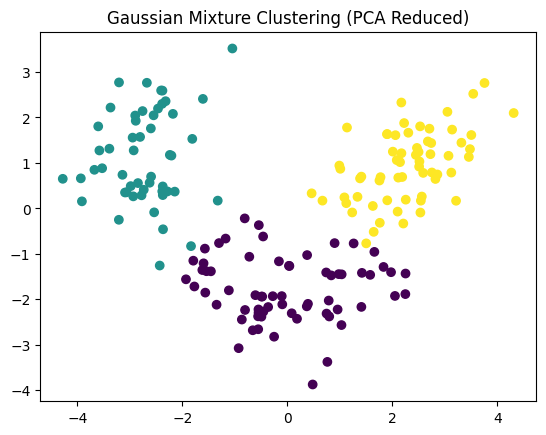

Davies-Bouldin Score (GMM): 1.3891879777181646


In [13]:
# Applying Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(df_scaled)
df['cluster_gmm'] = gmm_labels

# Visualizing GMM clusters
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df['cluster_gmm'], cmap='viridis')
plt.title('Gaussian Mixture Clustering (PCA Reduced)')
plt.show()

# Evaluate GMM using Davies-Bouldin score
db_score_gmm = davies_bouldin_score(df_scaled, gmm_labels)
print(f'Davies-Bouldin Score (GMM): {db_score_gmm}')


GMM can also be used for anomaly detection by identifying data points with low probability under the fitted Gaussian distributions.

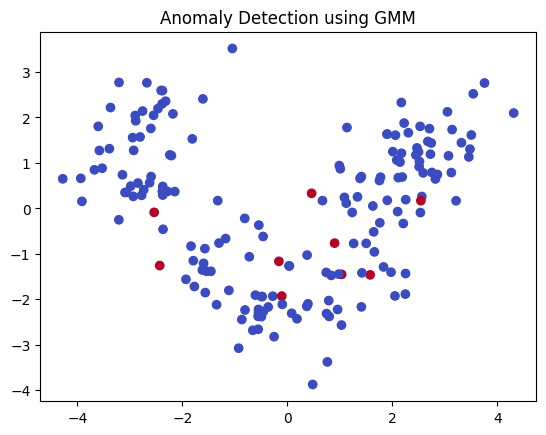

Number of detected anomalies: 9


In [14]:
# Anomaly Detection with GMM
probs         = gmm.predict_proba(df_scaled)
anomaly_score = -np.max(probs, axis=1)  # Low probability points are potential anomalies

# Threshold for anomalies
threshold = np.percentile(anomaly_score, 95)  # Top 5% anomalies
anomalies = anomaly_score > threshold

# Visualize anomalies
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=anomalies, cmap='coolwarm')
plt.title('Anomaly Detection using GMM')
plt.show()

# Print the number of anomalies
print(f'Number of detected anomalies: {np.sum(anomalies)}')
